In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

from counterfactuals.cf_methods import PPCEF
from counterfactuals.datasets.file_dataset import FileDataset
from counterfactuals.losses import BinaryDiscLoss
from counterfactuals.models import MaskedAutoregressiveFlow
from counterfactuals.models.classifier.multilayer_perceptron import MLPClassifier
from counterfactuals.metrics.orchestrator import MetricsOrchestrator
from counterfactuals.datasets.file_dataset import FileDataset

/Users/lukasz/genwro/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Prepare the data
dataset = FileDataset(config_path="../config/datasets/moons.yaml")

# Get the split data that's already available
X_train = dataset.X_train
X_test = dataset.X_test
y_train = dataset.y_train
y_test = dataset.y_test

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Train a discriminative model
num_inputs = X_train.shape[1]
num_targets = 1

In [4]:
discriminative_model = MLPClassifier(num_inputs, num_targets, [128, 128, 128], dropout=0.0)
discriminative_model.fit(
    train_dataloader,
    test_dataloader,
    epochs=5000,
    patience=300,
    lr=1e-3,
)

Epoch 376, Train: 0.0057, test: 0.0048, patience: 300:   8%|▊         | 377/5000 [00:08<01:38, 46.79it/s]


In [7]:
# Train a generative model
num_inputs = X_train.shape[1]
num_targets = 1

generative_model = MaskedAutoregressiveFlow(
    features=num_inputs,
    hidden_features=128,
    context_features=num_targets,
)
generative_model.fit(
    train_dataloader, test_dataloader, epochs=10000, patience=600, lr=0.01
)
log_prob_threshold = np.median(generative_model.predict_log_prob(test_dataloader))

Epoch 51, Train: 1.1190, test: 1.6952, patience: 31:   1%|          | 52/10000 [00:06<21:34,  7.69it/s]   


KeyboardInterrupt: 

In [ ]:
X_test_orig = X_test[y_test==0]
y_test_orig = y_test[y_test==0]

cf_dataset = TensorDataset(
    torch.tensor(X_test_orig, dtype=torch.float32), torch.tensor(y_test_orig, dtype=torch.float32)
)

In [ ]:
cf_dataloader = DataLoader(cf_dataset, batch_size=1024, shuffle=False)


cf_method = PPCEF(
    disc_model=discriminative_model,
    gen_model=generative_model,
    disc_model_criterion=BinaryDiscLoss(),
)

results = cf_method.explain_dataloader(
    cf_dataloader,
    alpha=100,
    log_prob_threshold=log_prob_threshold,
    epochs=5000,
    patience=600,
    lr=0.001,
)

Discriminator loss: 0.0000, Prob loss: 5.4849: 100%|██████████| 5000/5000 [00:14<00:00, 341.75it/s]


In [ ]:
ys_target = np.abs(1 - y_test_orig)


metrics_cf = MetricsOrchestrator(
    disc_model=discriminative_model,
    gen_model=generative_model,
    X_cf=results.x_cfs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test_orig,
    y_test=y_test_orig,
    y_target=ys_target,
    continuous_features=[0, 1],
    categorical_features=[],
    ratio_cont=None,
    prob_plausibility_threshold=log_prob_threshold,
    metrics_conf_path="../config/metrics/plausibility.yaml",
)
metrics = metrics_cf.calculate_all_metrics()

2025-10-16 17:20:55,070 - counterfactuals.metrics.orchestrator - INFO - Initialized MetricsOrchestrator with 99 counterfactuals, 99 valid


In [ ]:
metrics

{'coverage': 1.0,
 'validity': 1.0,
 'actionability': 0.0,
 'sparsity': 1.0,
 'proximity_categorical_hamming': 1.36321824510537,
 'proximity_categorical_jaccard': 1.36321824510537,
 'proximity_continuous_manhattan': 1.8185754767783167,
 'proximity_continuous_euclidean': 1.36321824510537,
 'proximity_continuous_mad': 3.7120008890453584,
 'proximity_l2_jaccard': 1.36321824510537,
 'proximity_mad_hamming': 3.7120008890453584,
 'prob_plausibility': 0.3333333333333333,
 'log_density_cf': -2.0037544,
 'log_density_test': -0.52366173,
 'lof_scores_cf': 1.591730623806383,
 'lof_scores_test': 1.0721709410716256,
 'isolation_forest_scores_cf': -0.025089778530190534,
 'isolation_forest_scores_test': 0.00497389017100576}

/Users/lukasz/genwro/counterfactuals/counterfactuals/plotting/counterfactual_visualization.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lukasz/genwro/counterfactuals/counterfactuals/plotting/counterfactual_visualization.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


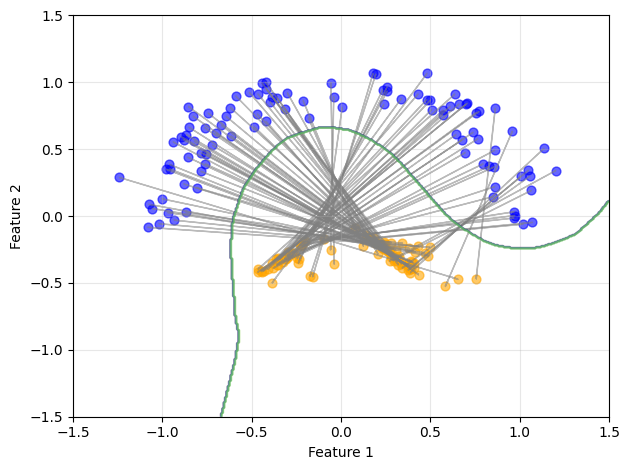

In [ ]:
from counterfactuals.plotting.counterfactual_visualization import plot_counterfactuals

plot_counterfactuals(X_test_orig, results.x_cfs, generative_model, discriminative_model, region_area_x=[-1.5, 1.5], region_area_y=[-1.5, 1.5])

In [ ]:
import pandas as pd
s
from counterfactuals.cf_methods import CCHVAE
from counterfactuals.cf_methods.local.c_chvae.mlmodel import CustomMLModel
from counterfactuals.cf_methods.local.c_chvae.data import CustomData

custom_dataset = CustomData(dataset)
wrapped_model = CustomMLModel(discriminative_model, custom_dataset)

input_size = dataset.X_train.shape[1]

cf_method = CCHVAE(
    mlmodel=wrapped_model,
    hyperparams={
        "data_name": "moons",
        "vae_params": {"layers": [input_size, 64, 32, 16]},
    },
)
target_class = 1
X_test_origin = dataset.X_test[dataset.y_test != target_class]
y_test_origin = dataset.y_test[dataset.y_test != target_class]

factuals = pd.DataFrame(X_test_origin, columns=wrapped_model.feature_input_order)
results = cf_method.get_counterfactuals_without_check(factuals)
results_arr = results.to_numpy()

Discriminator loss: 0.0000, Prob loss: 5.4849: 100%|██████████| 5000/5000 [00:14<00:00, 341.75it/s]


In [ ]:
ys_target = np.abs(1 - y_test_orig)


metrics_cf = MetricsOrchestrator(
    disc_model=discriminative_model,
    gen_model=generative_model,
    X_cf=results_arr,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test_orig,
    y_test=y_test_orig,
    y_target=ys_target,
    continuous_features=[0, 1],
    categorical_features=[],
    ratio_cont=None,
    prob_plausibility_threshold=log_prob_threshold,
    metrics_conf_path="../config/metrics/plausibility.yaml",
)
metrics = metrics_cf.calculate_all_metrics()

2025-10-16 17:20:55,070 - counterfactuals.metrics.orchestrator - INFO - Initialized MetricsOrchestrator with 99 counterfactuals, 99 valid


In [ ]:
metrics

{'coverage': 1.0,
 'validity': 1.0,
 'actionability': 0.0,
 'sparsity': 1.0,
 'proximity_categorical_hamming': 1.36321824510537,
 'proximity_categorical_jaccard': 1.36321824510537,
 'proximity_continuous_manhattan': 1.8185754767783167,
 'proximity_continuous_euclidean': 1.36321824510537,
 'proximity_continuous_mad': 3.7120008890453584,
 'proximity_l2_jaccard': 1.36321824510537,
 'proximity_mad_hamming': 3.7120008890453584,
 'prob_plausibility': 0.3333333333333333,
 'log_density_cf': -2.0037544,
 'log_density_test': -0.52366173,
 'lof_scores_cf': 1.591730623806383,
 'lof_scores_test': 1.0721709410716256,
 'isolation_forest_scores_cf': -0.025089778530190534,
 'isolation_forest_scores_test': 0.00497389017100576}

/Users/lukasz/genwro/counterfactuals/counterfactuals/plotting/counterfactual_visualization.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lukasz/genwro/counterfactuals/counterfactuals/plotting/counterfactual_visualization.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


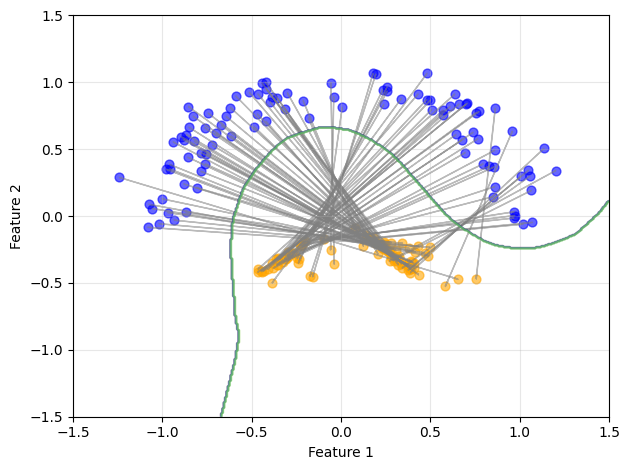

In [ ]:
from counterfactuals.plotting.counterfactual_visualization import plot_counterfactuals

plot_counterfactuals(X_test_orig, results_arr, generative_model, discriminative_model, region_area_x=[-1.5, 1.5], region_area_y=[-1.5, 1.5])